## Set-up environment

In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
!pip install -q git+https://github.com/huggingface/peft.git transformers bitsandbytes datasets

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.8/119.8 MB 8.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 547.8/547.8 kB 45.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 314.1/314.1 kB 32.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 MB 18.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 12.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 6.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 17.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 16.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.3/21.3 MB 70.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is t

## Load the image captioning dataset



In [19]:
import csv
import os
from PIL import Image
from datasets import Dataset

def dataset_generation(csv_file, image_folder):
    images = []
    captions = []
    Dict = {}
    with open(csv_file, 'r') as csvfile:
        datareader = csv.reader(csvfile)
        file_to_caption = {row[0]: row[1] for row in datareader if row}
    for filename in os.listdir(image_folder):
        if filename in file_to_caption:
            image_path = os.path.join(image_folder, filename)
            image = Image.open(image_path)
            images.append(image)
            captions.append(file_to_caption[filename])
    Dict['image'] = images
    Dict['text'] = captions
    dataset = Dataset.from_dict(Dict)
    return dataset


In [33]:
dataset = dataset_generation('/content/drive/MyDrive/LLM final project/image_dataset 2.csv','/content/drive/MyDrive/LLM final project/augmented images final')
dataset

Dataset({
    features: ['image', 'text'],
    num_rows: 169
})

In [34]:
from torch.utils.data import random_split

dataset_size = len(dataset)
train_size = int(0.8 * dataset_size)
val_size = dataset_size - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
print(f"Number of training examples: {len(train_dataset)}")
print(f"Number of validation examples: {len(val_dataset)}")

Number of training examples: 135
Number of validation examples: 34


In [35]:
dataset[0]["text"]

"grasping location: bottle's body"

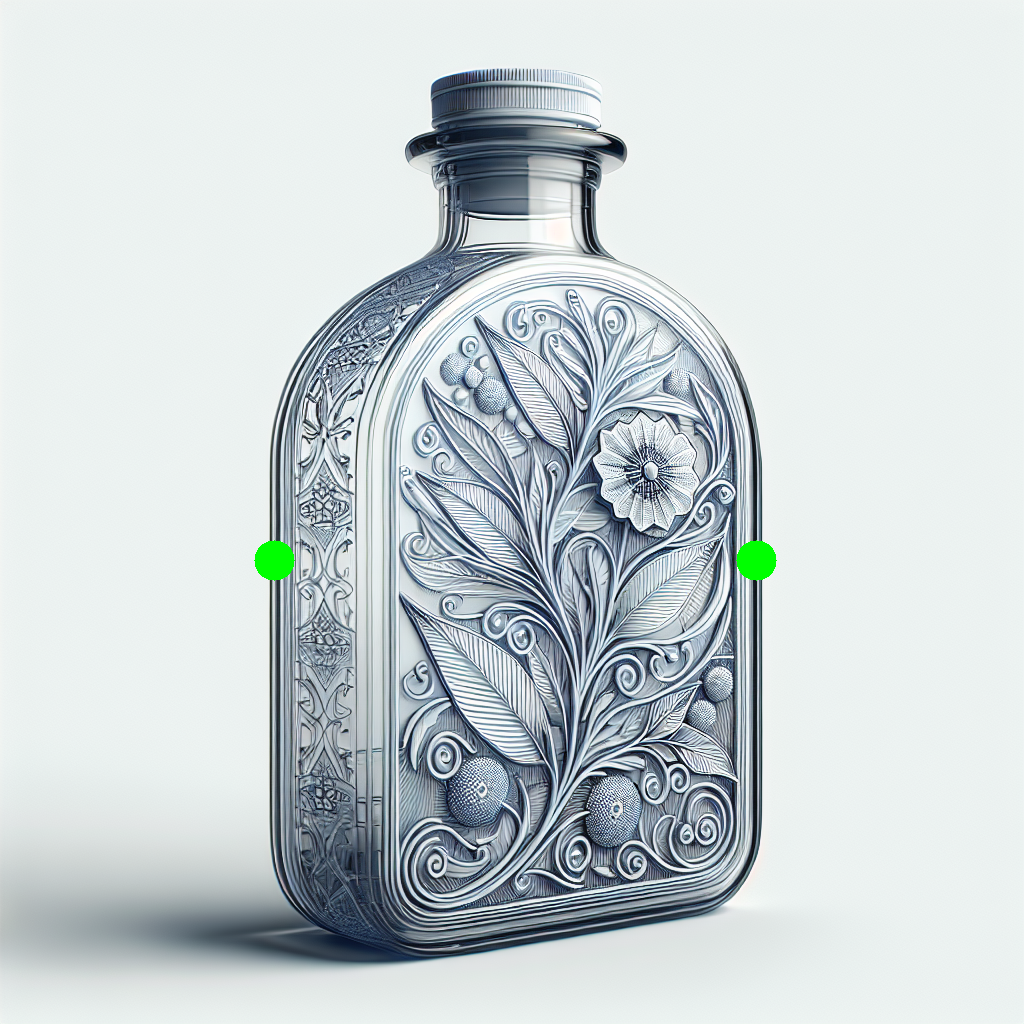

In [36]:
dataset[0]["image"]

## Create PyTorch Dataset

below we will define the dataset as well as the data collator!

In [7]:
from torch.utils.data import Dataset, DataLoader

class ImageCaptioningDataset(Dataset):
    def __init__(self, dataset, processor):
        self.dataset = dataset
        self.processor = processor

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        item = self.dataset[idx]
        encoding = self.processor(images=item["image"], padding="max_length", return_tensors="pt")
        # remove batch dimension
        encoding = {k: v.squeeze() for k, v in encoding.items()}
        encoding["text"] = item["text"]
        return encoding

def collate_fn(batch):
    # pad the input_ids and attention_mask
    processed_batch = {}
    for key in batch[0].keys():
        if key != "text":
            processed_batch[key] = torch.stack([example[key] for example in batch])
        else:
            text_inputs = processor.tokenizer(
                [example["text"] for example in batch], padding=True, return_tensors="pt"
            )
            processed_batch["input_ids"] = text_inputs["input_ids"]
            processed_batch["attention_mask"] = text_inputs["attention_mask"]
    return processed_batch


## Load model and processor

In [37]:
from transformers import AutoProcessor, BlipForConditionalGeneration
import torch
processor = AutoProcessor.from_pretrained("Salesforce/blip-image-captioning-large")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-large" ,torch_dtype=torch.float16).to("cuda")


Next we define our `LoraConfig` object.

In [38]:
from peft import LoraConfig, get_peft_model

# Let's define the LoraConfig
config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    target_modules=[
        "self.query",
        "self.key",
        "self.value",
        "output.dense",
        "self_attn.qkv",
        "self_attn.projection",
        "mlp.fc1",
        "mlp.fc2",
    ],
)

model = get_peft_model(model, config)
model.print_trainable_parameters()

trainable params: 9,486,336 || all params: 479,219,260 || trainable%: 1.9795


Now we have loaded the processor, let's load the dataset and the dataloader:

In [39]:
train_dataset = ImageCaptioningDataset(train_dataset, processor)
train_dataloader = DataLoader(train_dataset, shuffle=True, batch_size=3, collate_fn=collate_fn)

val_dataset = ImageCaptioningDataset(val_dataset, processor)
val_dataloader = DataLoader(val_dataset, batch_size=3, collate_fn=collate_fn)

## Train the model

In [40]:
import torch
import matplotlib.pyplot as plt


optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)

device = "cuda" if torch.cuda.is_available() else "cpu"

model.train()
train_losses = []
val_losses = []


for epoch in range(25):
    print("Epoch:", epoch)

    # Training loop
    model.train()
    train_loss_epoch = 0
    for idx, batch in enumerate(train_dataloader):
        input_ids = batch.pop("input_ids").to(device)
        pixel_values = batch.pop("pixel_values").to(device, torch.float16)
        attention_mask = batch.pop("attention_mask").to(device)

        outputs = model(input_ids=input_ids,
                        pixel_values=pixel_values,
                        attention_mask=attention_mask,
                        labels=input_ids)


        train_loss = outputs.loss
        train_loss_epoch += train_loss.item()

        train_loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    # Validation loop
    model.eval()
    val_loss_epoch = 0
    with torch.no_grad():
        for val_batch in val_dataloader:
            val_input_ids = val_batch.pop("input_ids").to(device)
            val_pixel_values = val_batch.pop("pixel_values").to(device, torch.float16)
            val_attention_mask = val_batch.pop("attention_mask").to(device)

            val_outputs = model(input_ids=val_input_ids,
                                pixel_values=val_pixel_values,
                                attention_mask=val_attention_mask,
                                labels=val_input_ids)

            val_loss = val_outputs.loss
            val_loss_epoch += val_loss.item()


    train_loss_epoch /= len(train_dataloader)
    train_losses.append(train_loss_epoch)
    val_loss_epoch /= len(val_dataloader)
    val_losses.append(val_loss_epoch)
    print(f"Validation Loss (Epoch {epoch}):", val_loss_epoch)
    print(f"Trainig Loss (Epoch {epoch}):", train_loss_epoch)



Epoch: 0
Validation Loss (Epoch 0): 1.5843912760416667
Trainig Loss (Epoch 0): 2.593619791666667
Epoch: 1
Validation Loss (Epoch 1): 1.4978841145833333
Trainig Loss (Epoch 1): 1.6404296875
Epoch: 2
Validation Loss (Epoch 2): 1.4979654947916667
Trainig Loss (Epoch 2): 1.5291883680555556
Epoch: 3
Validation Loss (Epoch 3): 1.354736328125
Trainig Loss (Epoch 3): 1.4432725694444444
Epoch: 4
Validation Loss (Epoch 4): 1.5567220052083333
Trainig Loss (Epoch 4): 1.3871527777777777
Epoch: 5
Validation Loss (Epoch 5): 1.4402669270833333
Trainig Loss (Epoch 5): 1.5776475694444445
Epoch: 6
Validation Loss (Epoch 6): 1.4527180989583333
Trainig Loss (Epoch 6): 1.4245659722222221
Epoch: 7
Validation Loss (Epoch 7): 1.3741048177083333
Trainig Loss (Epoch 7): 1.34208984375
Epoch: 8
Validation Loss (Epoch 8): 1.4440104166666667
Trainig Loss (Epoch 8): 1.3383138020833334
Epoch: 9
Validation Loss (Epoch 9): 1.4223225911458333
Trainig Loss (Epoch 9): 1.3348741319444444
Epoch: 10
Validation Loss (Epoch 10)

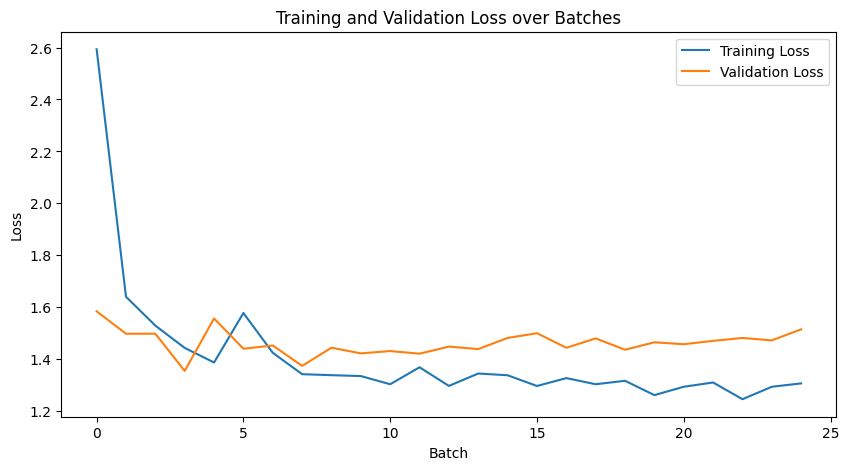

In [41]:
# Plot the losses
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Batch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss over Batches')
plt.legend()
plt.show()

## Inference

In [42]:
# load image

cup_base = Image.open("/content/drive/MyDrive/LLM final project/sample images/cup_base.jpeg")
cup_handle2 = Image.open("/content/drive/MyDrive/LLM final project/sample images/cup_handle2.jpeg")
cup_handle3 = Image.open("/content/drive/MyDrive/LLM final project/sample images/cup_handle3.jpg")


remote_base = Image.open("/content/drive/MyDrive/LLM final project/sample images/remote_base.jpeg")
remote_body = Image.open("/content/drive/MyDrive/LLM final project/sample images/remote_body.jpeg")

toothbrush_body = Image.open("/content/drive/MyDrive/LLM final project/sample images/toothbrush_body.jpeg")
toothbrush_head = Image.open("/content/drive/MyDrive/LLM final project/sample images/toothbrush_head.jpeg")

vase_body = Image.open("/content/drive/MyDrive/LLM final project/sample images/vase_body.jpeg")
vase_neck = Image.open("/content/drive/MyDrive/LLM final project/sample images/vase_neck.jpeg")

wine_glass_body = Image.open("/content/drive/MyDrive/LLM final project/sample images/wine glass_body.jpeg")
wine_glass_stem = Image.open("/content/drive/MyDrive/LLM final project/sample images/wine glass_stem.jpeg")
wine_glass_edge = Image.open("/content/drive/MyDrive/LLM final project/sample images/wine glass_edge.jpeg")




In [28]:
def generate_caption(image,model):
  text = "grasping location: "
  inputs = processor(images=image,text=text, return_tensors="pt").to(device, torch.float16)
  pixel_values = inputs.pixel_values

  generated_ids = model.generate(pixel_values=pixel_values, max_length=25)
  generated_caption = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
  return generated_caption

In [43]:

import matplotlib.pyplot as plt

# Define the images and captions
images = [cup_handle2,cup_handle3,cup_base,remote_base,remote_body,toothbrush_body,toothbrush_head,vase_body,vase_neck,wine_glass_body,wine_glass_stem,wine_glass_edge]
captions = [generate_caption(cup_handle2,model),
            generate_caption(cup_handle3,model),
            generate_caption(cup_base,model),
            generate_caption(remote_base,model),
            generate_caption(remote_body,model),
            generate_caption(toothbrush_body,model),
            generate_caption(toothbrush_head,model),
            generate_caption(vase_body,model),
            generate_caption(vase_neck,model),
            generate_caption(wine_glass_body,model),
            generate_caption(wine_glass_stem,model),
            generate_caption(wine_glass_edge,model)]



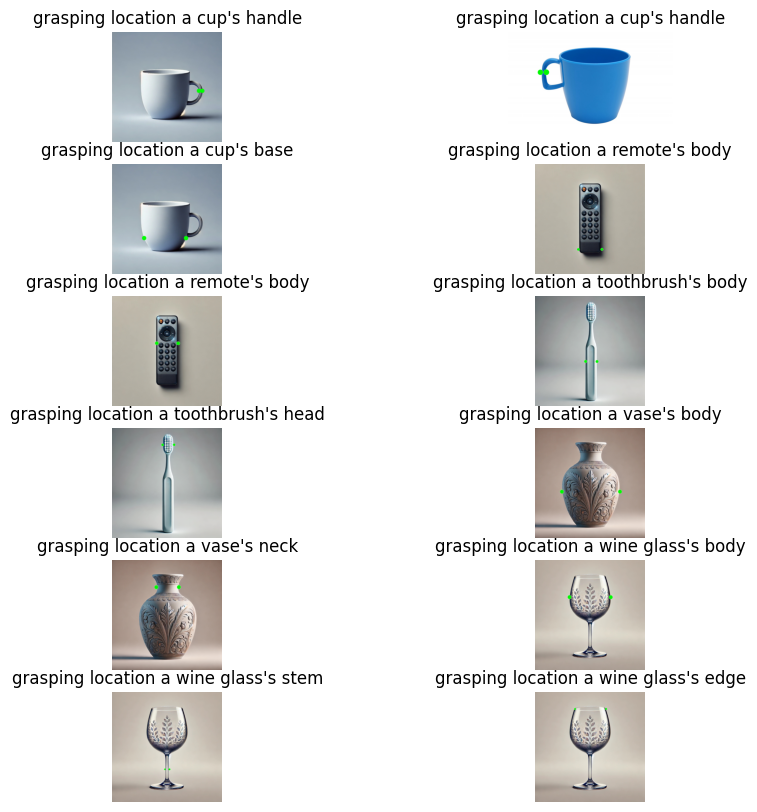

In [32]:
# Create the figure and subplots
fig, axs = plt.subplots(6, 2, figsize=(10, 10))

# Plot each image and its caption
for idx, (image, caption) in enumerate(zip(images, captions)):
    ax = axs[idx // 2, idx % 2]
    ax.imshow(image)
    ax.set_title(caption)
    ax.axis("off")

# Show the plot
plt.show()


### Saving the model

In [ ]:
model.save_pretrained("/content/drive/MyDrive/LLM final project/fine-tuned model")